In [322]:
import math
import random
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import multiprocessing as mp
from collections import namedtuple, deque

from utils import annotated_heatmap, analytical_policy_evaluation, epsilon_greedy_policy
from plotting import plot_policy

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import gymnasium as gym

# if GPU is to be used
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)

In [323]:
# Configuration
NUM_ENVS = 8
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def make_env():
    # Wrap the custom environment to track rewards and lengths automatically
    env = gym.make("CartPole-v1")
    return gym.wrappers.RecordEpisodeStatistics(env)

N_STATES = 4
N_ACTIONS = 2
ROLLOUT_SAMPLES = 1000
MINI_BATCH_SIZE = 256

In [324]:
class PolicyNetwork(nn.Module):
    def __init__(self, n_states, n_hidden, n_actions):
        super().__init__()
        self.affine1 = nn.Linear(n_states, n_hidden)
        self.affine2 = nn.Linear(n_hidden, n_hidden)
        self.action_head = nn.Linear(n_hidden, n_actions)

    def forward(self, x):
        if not isinstance(x, torch.Tensor):
            x = torch.tensor(x, dtype=torch.float32).to(DEVICE)
            
        x = F.relu(self.affine1(x))
        x = F.relu(self.affine2(x))
        return self.action_head(x) # Returns raw logits

    def full_pass(self, x):
        logits = self.forward(x)
        dist = torch.distributions.Categorical(logits=logits)
        action = dist.sample()
        return action, dist.log_prob(action), dist.entropy()

class ValueNetwork(nn.Module):
    def __init__(self, n_states, n_hidden):
        super().__init__()
        self.affine1 = nn.Linear(n_states, n_hidden)
        self.affine2 = nn.Linear(n_hidden, n_hidden)
        self.value_head = nn.Linear(n_hidden, 1)

    def forward(self, x):
        if not isinstance(x, torch.Tensor):
            x = torch.tensor(x, dtype=torch.float32).to(DEVICE)
  
        x = F.relu(self.affine1(x))
        x = F.relu(self.affine2(x))
        return self.value_head(x).squeeze(-1) # Shape: (batch_size)

In [325]:
Transition = namedtuple('Transition',
                        ('states', 'actions', 'log_prob', 'entropy', 'rewards', 'values', 'dones'))

# next_states, rewards, terms, truncs, infos

class RolloutBuffer(object):

    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        """Save a transition"""
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        mini_batch = random.sample(self.memory, batch_size)
        return self.flatten(mini_batch)

    def clear(self):
        self.memory.clear()

    def flatten(self, buffer):
        # 1. Unzip the list of namedtuples
        batch = Transition(*zip(*buffer))

        # 2. Concatenate the lists/tuples into single Tensors
        # Using torch.stack or torch.cat depending on the original shape
        states = torch.tensor(np.array(batch.states), dtype=torch.float32).to(DEVICE).reshape(-1, N_STATES)
        
        # Flattening [steps, envs] -> [steps * envs]
        actions = torch.cat(batch.actions).flatten()
        log_probs = torch.cat(batch.log_prob).flatten()
        rewards = torch.tensor(batch.rewards, dtype=torch.float32).to(DEVICE).flatten()
        entropys = torch.cat(batch.entropy).flatten()
        values = torch.cat(batch.values).flatten()
        dones = torch.tensor(batch.dones, dtype=torch.float32).to(DEVICE).flatten()

        return states, actions, log_probs, entropys, rewards, values, dones
        
    def get_batch(self):
        return self.flatten(self.memory)

    def __len__(self):
        return len(self.memory)

In [326]:
def rollout(envs, buffer, actor, critic, number_of_samples):
    states, _ = envs.reset()
    avg_returns = []
    rewards_counter = np.zeros((1, NUM_ENVS))
    for step in range(number_of_samples):
        values = critic(states)
        actions, log_probs, entropy = actor.full_pass(states)
        next_states, rewards, terminated, truncated, infos = envs.step(actions.cpu().numpy())
        dones = terminated | truncated
        buffer.push(states, actions, log_probs, entropy, rewards, values, dones)
        states = next_states
        if "episode" in infos:
            avg_returns.append(np.array(infos["episode"]["r"]).mean())
    return np.array(avg_returns).mean()

In [327]:
def compute_targets(rewards, dones, gamma):
    # rewards and dones are flattened tensors from buffer.get_batch()
    # shape: (ROLLOUT_SAMPLES * NUM_ENVS,)
    
    n = len(rewards)
    targets = torch.zeros_like(rewards)
    running_return = 0
    
    # Iterate backwards through the batch
    for t in reversed(range(n)):
        # If the episode ended at this step, the future return is 0
        if dones[t]:
            running_return = 0
            
        running_return = rewards[t] + gamma * running_return
        targets[t] = running_return
        
    return targets

In [336]:
def train_ppo(envs, total_steps=100, gamma=0.99, lr=1e-3):
    policy = PolicyNetwork(N_STATES, 32, N_ACTIONS).to(DEVICE)
    vnet = ValueNetwork(N_STATES, 32).to(DEVICE)
    optimizer = optim.Adam(list(policy.parameters()) + list(vnet.parameters()), lr=lr)

    episodic_returns = []

    buffer = RolloutBuffer(ROLLOUT_SAMPLES)

    for step in tqdm(range(total_steps)):
        # 1. Collect Batch
        # actions, log_probs, entropy = policy.full_pass(states)
        # next_states, rewards, terms, truncs, infos = envs.step(actions.cpu().numpy())
        episodic_return = rollout(envs, buffer, policy, vnet, number_of_samples=ROLLOUT_SAMPLES) 
        episodic_returns.append(episodic_return)

        b_states, b_actions, b_log_probs, b_entropy, b_rewards, b_values, b_dones = buffer.get_batch()

        # 3. Calculate Targets and Advantages
        b_targets = compute_targets(b_rewards, b_dones, gamma)
        b_advantages = b_targets - b_values

        # Normalise the advantage
        b_advantages = (b_advantages - b_advantages.mean()) / (b_advantages.std() + 1e-8)

        batch_size = b_states.shape[0] # 8000
        mini_batch_size = 64
        num_epochs = 5

        for epoch in range(num_epochs):
            # print("Epoch", epoch)
            # Generate a random permutation of indices for this epoch
            indices = np.random.permutation(batch_size)
    
            for start in range(0, batch_size, mini_batch_size):
                idx = indices[start : start + mini_batch_size]
        
                # Slice the mini-batch using the indices
                mb_advantages = b_advantages[idx]
                mb_states = b_states[idx]
                mb_actions = b_actions[idx]
                mb_log_probs = b_log_probs[idx]
                mb_targets = b_targets[idx]
                mb_entropy = b_entropy[idx]
                
                logits = policy.forward(mb_states)
                dist = torch.distributions.Categorical(logits=logits)
                predicted_log_probs = dist.log_prob(mb_actions)
                predicted_entropy = dist.entropy()

                predicted_values = vnet(mb_states)
                ratios = torch.exp(predicted_log_probs - mb_log_probs.detach())
                # Calculate surrogate losses.
                unclipped_surrogate_loss = ratios * mb_advantages.detach()
                clipped_surrogate_loss = torch.clamp(ratios, 1 - 0.2, 1 + 0.2) * mb_advantages.detach()
                policy_loss = (-torch.min(unclipped_surrogate_loss, clipped_surrogate_loss)).mean()
            
                # 4. Losses 
                value_loss = F.mse_loss(predicted_values, mb_targets.detach())
        
                # Total Loss with Entropy Bonus (0.01)
                loss = policy_loss + 0.5 * value_loss - 0.01 * predicted_entropy.mean()

                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(list(policy.parameters()) + list(vnet.parameters()), 0.5)
                optimizer.step()
                
        buffer.clear()

    return episodic_returns

In [337]:
# In your "Run Training" cell:
envs = gym.vector.AsyncVectorEnv([make_env for _ in range(NUM_ENVS)])
returns = train_ppo(envs)
envs.close()

 23%|███████████████▏                                                  | 23/100 [01:01<03:27,  2.69s/it]


KeyboardInterrupt: 

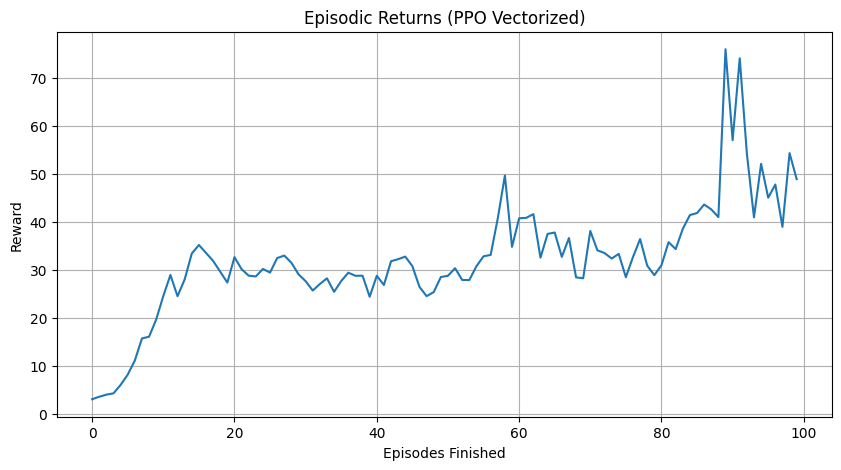

In [333]:
plt.figure(figsize=(10, 5))
plt.plot(returns)
plt.title("Episodic Returns (PPO Vectorized)")
plt.xlabel("Episodes Finished")
plt.ylabel("Reward")
plt.grid(True)
plt.show()